In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppresses TensorFlow warnings

# Optional: suppress logging from TensorFlow itself
import tensorflow as tf
tf.get_logger().setLevel('ERROR')


E0000 00:00:1745269738.753610      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745269738.816340      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.1
    Uninstalling typeguard-4.4.1:
      Successfully uninstalled typeguard-4.4.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 13.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.16.1 requires typeguard<5,>=3, but you have typeguard 2.13.3 which is incompatible.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.
Found 7028 files belonging to 4 classes.
Using 6326 files for training.


I0000 00:00:1745269764.097972      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 7028 files belonging to 4 classes.
Using 702 files for validation.


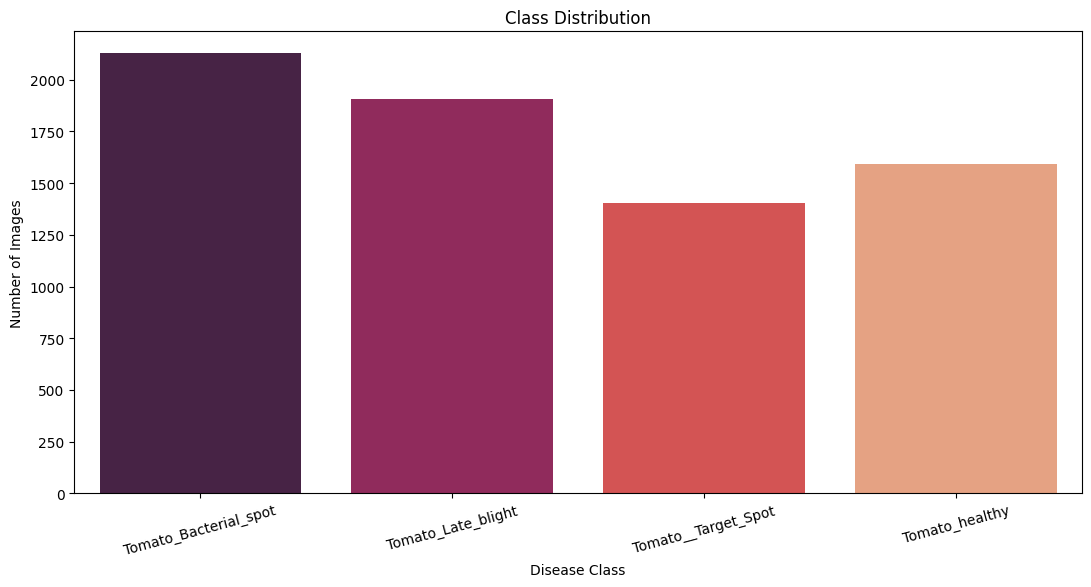

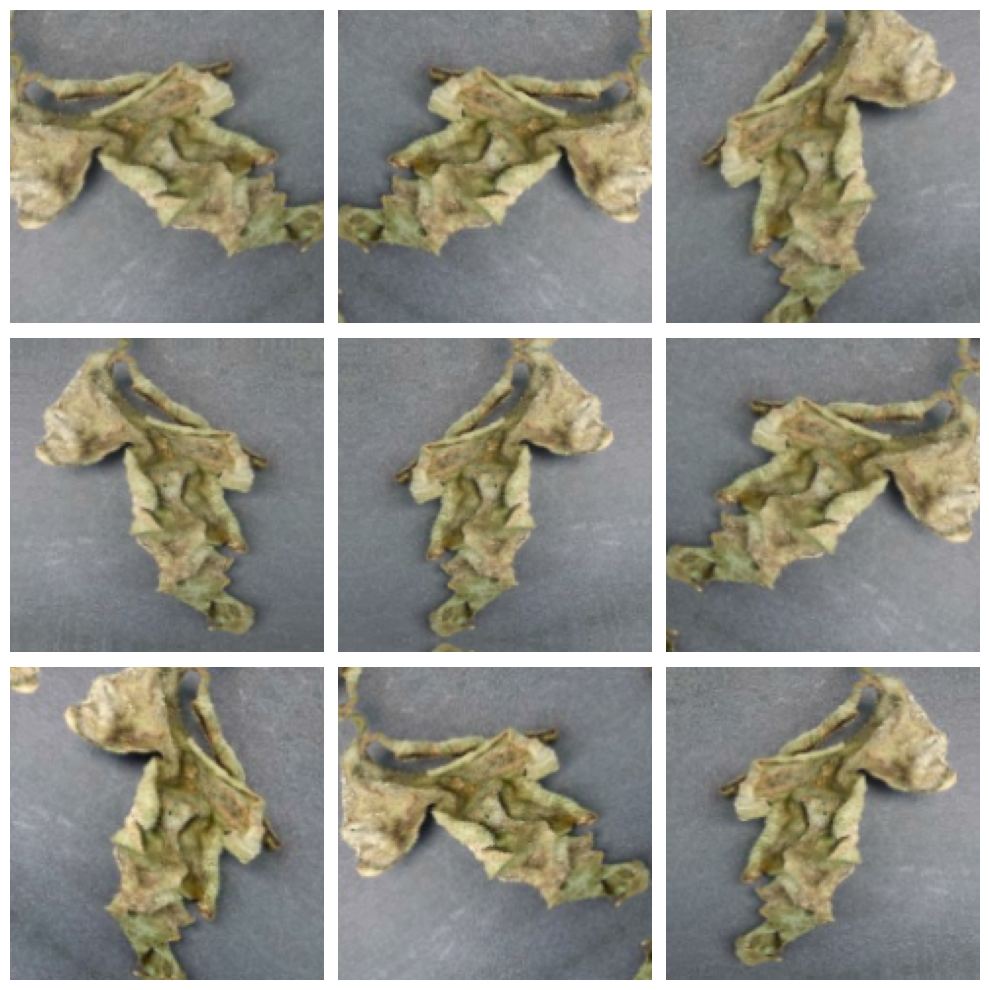

Model: "CvT_Enhanced"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 160, 160, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_embed_depthwise    │ (None, 80, 80, 3)      │             30 │ input_layer_1[0][0]    │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_embed_pointwise    │ (None, 80, 80, 64)     │            256 │ stage1_embed_depthwis… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_embed_bn           │ (None, 80, 80, 64)     │            256 │ stage1_embed_pointwis… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_embed_gelu         │ (None, 80, 80, 64)     │              0 │ stage1_embed_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 6400, 64)       │              0 │ stage1_embed_gelu[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_block0_ln1         │ (None, 6400, 64)       │            128 │ reshape[0][0]          │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_block0_mha         │ (None, 6400, 64)       │         16,640 │ stage1_block0_ln1[0][… │
│ (MultiHeadAttention)      │                        │                │ stage1_block0_ln1[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_block0_skip1 (Add) │ (None, 6400, 64)       │              0 │ reshape[0][0],         │
│                           │                        │                │ stage1_block0_mha[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_block0_ln2         │ (None, 6400, 64)       │            128 │ stage1_block0_skip1[0… │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_block0_ffn         │ (None, 6400, 64)       │         33,088 │ stage1_block0_ln2[0][… │
│ (Sequential)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_block0_skip2 (Add) │ (None, 6400, 64)       │              0 │ stage1_block0_skip1[0… │
│                           │                        │                │ stage1_block0_ffn[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_1 (Reshape)       │ (None, 80, 80, 64)     │              0 │ stage1_block0_skip2[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_2 (Reshape)       │ (None, 6400, 64)       │              0 │ reshape_1[0][0]        │
├──────────────────────

 Total params: 3,831,714 (14.62 MB)

 Trainable params: 3,830,818 (14.61 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/10


I0000 00:00:1745269799.104425      77 service.cc:148] XLA service 0x450f7d20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745269799.105111      77 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1745269801.628793      77 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1745269820.274017      77 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


396/396 ━━━━━━━━━━━━━━━━━━━━ 277s 574ms/step - accuracy: 0.7620 - loss: 0.6031 - val_accuracy: 0.4558 - val_loss: 4.6294 - learning_rate: 1.0000e-04
Epoch 2/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 202s 510ms/step - accuracy: 0.9034 - loss: 0.2643 - val_accuracy: 0.8889 - val_loss: 0.3366 - learning_rate: 1.0000e-04
Epoch 3/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 202s 510ms/step - accuracy: 0.9331 - loss: 0.1879 - val_accuracy: 0.7977 - val_loss: 1.0941 - learning_rate: 1.0000e-04
Epoch 4/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 202s 510ms/step - accuracy: 0.9476 - loss: 0.1456 - val_accuracy: 0.6553 - val_loss: 2.0145 - learning_rate: 1.0000e-04
Epoch 5/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 202s 510ms/step - accuracy: 0.9740 - loss: 0.0699 - val_accuracy: 0.8661 - val_loss: 0.4615 - learning_rate: 1.0000e-05
Epoch 6/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 202s 510ms/step - accuracy: 0.9837 - loss: 0.0477 - val_accuracy: 0.8519 - val_loss: 0.5802 - learning_rate: 1.0000e-05
Epoch 7/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 202s 510ms/

In [2]:
!pip install typeguard==4.0.1
!pip install -q tensorflow tensorflow-addons
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# === Dataset Setup ===
IMG_SIZE = (160, 160)
BATCH_SIZE = 16
SEED = 42
directory = "/kaggle/input/tomato-leaf-diseases/Tomato Leaf Diseases Dataset From Bangladesh"

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    directory,
    validation_split=0.1,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    directory,
    validation_split=0.1,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

class_names = train_dataset.class_names
num_classes = len(class_names)

# === Class Weights ===
data_imbalance = [len(glob.glob(os.path.join(directory, class_folder, '*.*'))) for class_folder in class_names]
total_images = sum(data_imbalance)
class_weight = {
    i: (1.0 / count) * (total_images / len(data_imbalance))
    for i, count in enumerate(data_imbalance)
}



# Visualize distribution
plt.figure(figsize=(13, 6))
sns.barplot(x=class_names, y=data_imbalance, palette="rocket")
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Disease Class")
plt.xticks(rotation=15)
plt.show()






# === Data Augmentation & Preprocessing ===
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])



for image, _ in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    first_image = image[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        img = tf.cast(augmented_image[0], tf.float32) / 255.0
        plt.imshow(img)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


def augment_image(image, label):
    image = data_augmentation(image)
    return image, label

def preprocess_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_dataset = train_dataset.map(augment_image).map(preprocess_image).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)

# === CvT Utilities ===
def conv_embedding(x, filters, kernel_size=3, strides=1, name="conv_embed"):
    x = layers.DepthwiseConv2D(kernel_size, strides=strides, padding='same', name=f"{name}_depthwise")(x)
    x = layers.Conv2D(filters, 1, padding='same', name=f"{name}_pointwise")(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    x = layers.Activation("gelu", name=f"{name}_gelu")(x)
    return x

def transformer_encoder(x, num_heads, projection_dim, dropout=0.1, name="transformer"):
    # Save static shape
    H, W, C = x.shape[1], x.shape[2], x.shape[3]

    # Flatten spatial dimensions (H*W, C)
    x_flat = layers.Reshape((-1, C))(x)

    # LayerNorm + MultiHeadAttention
    x1 = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln1")(x_flat)
    attn_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=projection_dim, dropout=dropout, name=f"{name}_mha"
    )(x1, x1)
    x2 = layers.Add(name=f"{name}_skip1")([x_flat, attn_output])

    # Feedforward network
    x3 = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln2")(x2)
    ffn_output = keras.Sequential([
        layers.Dense(projection_dim * 4, activation="gelu"),
        layers.Dense(projection_dim),
    ], name=f"{name}_ffn")(x3)
    x4 = layers.Add(name=f"{name}_skip2")([x2, ffn_output])

    # Reshape back to (H, W, C)
    x_out = layers.Reshape((H, W, C))(x4)
    return x_out


def transformer_block_stage(x, num_blocks, num_heads, projection_dim, name="stage"):
    for i in range(num_blocks):
        x = transformer_encoder(x, num_heads=num_heads, projection_dim=projection_dim, name=f"{name}_block{i}")
    return x

# === CvT Model ===
def create_cvt_model(input_shape=(160, 160, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)

    # Stage 1
    x = conv_embedding(inputs, filters=64, strides=2, name="stage1_embed")
    x = transformer_block_stage(x, num_blocks=2, num_heads=1, projection_dim=64, name="stage1")

    # Stage 2
    x = conv_embedding(x, filters=128, strides=2, name="stage2_embed")
    x = transformer_block_stage(x, num_blocks=2, num_heads=2, projection_dim=128, name="stage2")

    # Stage 3
    x = conv_embedding(x, filters=256, strides=2, name="stage3_embed")
    x = transformer_block_stage(x, num_blocks=2, num_heads=4, projection_dim=256, name="stage3")

    # Classification
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="classifier")(x)

    return keras.Model(inputs, outputs, name="CvT_Enhanced")

# === Model Compilation & Training ===
model = create_cvt_model(input_shape=(160, 160, 3), num_classes=num_classes)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weight,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(patience=2)
    ]
)


In [3]:
test_loss, test_acc = model.evaluate(val_dataset)
print(f"Validation Accuracy: {test_acc:.2f}")


44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.8984 - loss: 0.3293
Validation Accuracy: 0.89


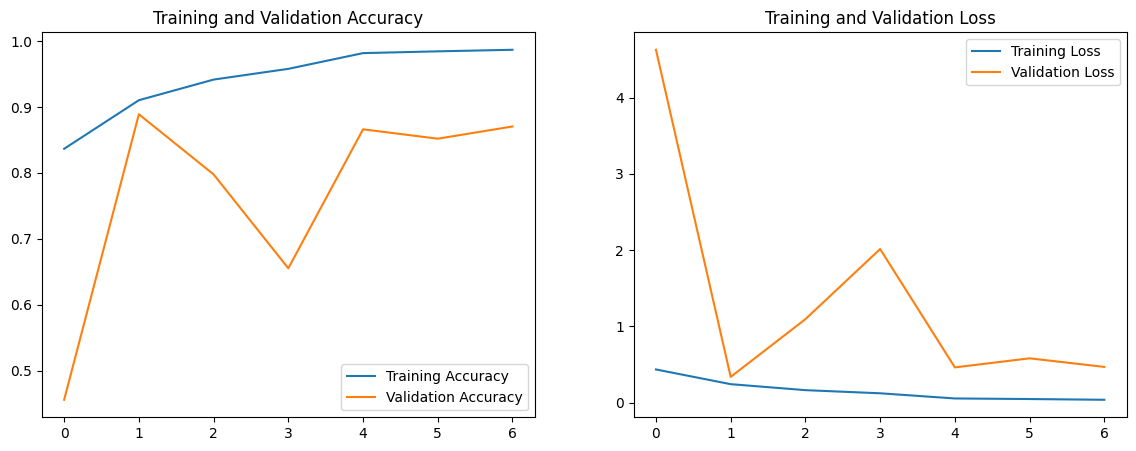

In [4]:
def plot_training(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.legend(loc="lower right")
    plt.title("Training and Validation Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.legend(loc="upper right")
    plt.title("Training and Validation Loss")
    plt.show()

plot_training(history)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━

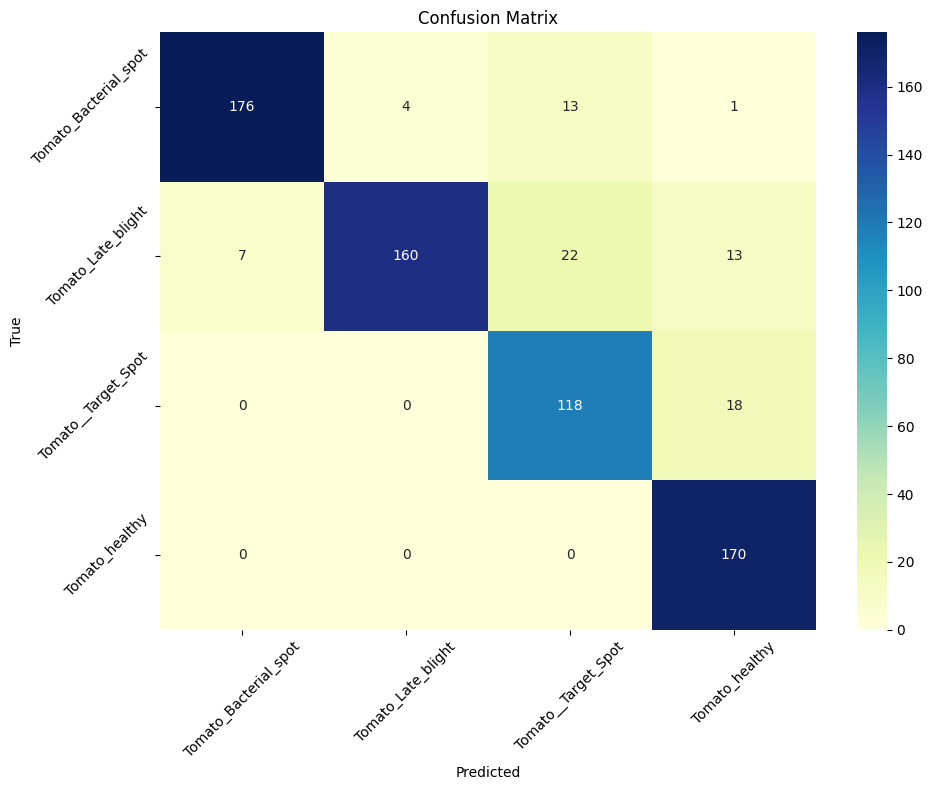


Classification Report:

                       precision    recall  f1-score   support

Tomato_Bacterial_spot       0.96      0.91      0.93       194
   Tomato_Late_blight       0.98      0.79      0.87       202
  Tomato__Target_Spot       0.77      0.87      0.82       136
       Tomato_healthy       0.84      1.00      0.91       170

             accuracy                           0.89       702
            macro avg       0.89      0.89      0.88       702
         weighted avg       0.90      0.89      0.89       702



In [5]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


# Get predictions
y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="YlGnBu")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))
